# Import

In [ ]:
import os
import bm25s
import numpy as np
import random
import pickle
import string
import math
import spacy

from scipy.stats import skew

from beir import util
from beir.datasets.data_loader import GenericDataLoader
from beir.retrieval.evaluation import EvaluateRetrieval
from beir.retrieval.search.dense import DenseRetrievalExactSearch as DRES
from beir.retrieval.models import SentenceBERT

# Add Data

In [2]:
def add_data(dataset_name: str):
    url = "https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/{}.zip".format(dataset_name)
    out_dir = os.path.join(os.getcwd(), "datasets")
    data_path = util.download_and_unzip(url, out_dir)
    return data_path

# Add Models

## Add Model Dense

In [3]:
def add_model_dense(model_name: str):
    dense_model = DRES(SentenceBERT(f"sentence-transformers/{model_name}"), batch_size=64)
    return dense_model

## Add model Sparse

In [4]:
def add_model_sparse():
    retriever = bm25s.BM25(method="lucene", k1=1.2, b=0.75)
    return retriever

# Prepare Data

In [5]:
class RunDatasets:
    def __init__(self):
        self.evaluator = EvaluateRetrieval()
        self.train_retrieval_data = {}
        self.test_retrieval_data = {}

    def normalize_scores(self, results):
        """Min-Max normalization of scores for BM25 and Dense."""
        normalized = {}
        for qid, docs in results.items():
            if not docs:
                continue
            scores = list(docs.values())
            min_s, max_s = min(scores), max(scores)

            normalized[qid] = {}
            for did, score in docs.items():
                if max_s > min_s:
                    normalized[qid][did] = (score - min_s) / (max_s - min_s)
                else:
                    normalized[qid][did] = 0.5
        return normalized

    def get_hybrid_scores(self, dense_res, sparse_res, alpha):
        """alpha * Dense + (1 - alpha) * Sparse."""
        hybrid = {}
        all_qids = set(dense_res.keys()) | set(sparse_res.keys())

        for qid in all_qids:
            hybrid[qid] = {}
            q_dense = dense_res.get(qid, {})
            q_sparse = sparse_res.get(qid, {})
            all_dids = set(q_dense.keys()) | set(q_sparse.keys())

            for did in all_dids:
                s_d = q_dense.get(did, 0.0)
                s_s = q_sparse.get(did, 0.0)
                hybrid[qid][did] = float(alpha * s_d + (1.0 - alpha) * s_s)

        return hybrid

    def _process_dataset(self, ds: str, split: str, sample_queries: int = None):
        """Core pipeline: loads data, runs retrieval, normalizes scores."""
        print(f"\n[{ds.upper()}] Loading data (split='{split}')...")
        data_path = add_data(ds)
        corpus, queries, qrels = GenericDataLoader(data_folder=data_path).load(split=split)

        corpus_ids = list(corpus.keys())
        corpus_texts = [f"{corpus[cid].get('title', '')} {corpus[cid].get('text', '')}" for cid in corpus_ids]
        query_ids = [qid for qid in queries.keys() if qid in qrels]
        if sample_queries and len(query_ids) > sample_queries:
            print(f"[{ds.upper()}] Subsampling queries from {len(query_ids)} to {sample_queries}...")
            query_ids = random.sample(query_ids, sample_queries)

        queries = {qid: queries[qid] for qid in query_ids}
        qrels = {qid: qrels[qid] for qid in query_ids if qid in qrels}

        query_texts = [queries[qid] for qid in query_ids]

        print(f"[{ds.upper()}] Building IDF dictionary...")
        df_dict = {}
        for text in corpus_texts:
            for token in set(text.lower().split()):
                df_dict[token] = df_dict.get(token, 0) + 1

        N = len(corpus_texts)
        idf_dict = {t: math.log(1 + (N - df + 0.5) / (df + 0.5)) for t, df in df_dict.items() if df > 0}
        vocab_set = set(df_dict.keys())

        print(f"[{ds.upper()}] Running Dense Retrieval...")
        dense_model = add_model_dense("all-MiniLM-L6-v2")
        dense_retriever = EvaluateRetrieval(dense_model, score_function="cos_sim")
        dense_raw = dense_retriever.retrieve(corpus, queries)

        print(f"[{ds.upper()}] Running Sparse Retrieval (BM25s)...")
        sparse_model = add_model_sparse()
        corpus_tokens = bm25s.tokenize(corpus_texts)
        sparse_model.index(corpus_tokens)

        query_tokens = bm25s.tokenize(query_texts)
        docs, scores = sparse_model.retrieve(query_tokens, corpus=corpus_ids, k=100)
        sparse_raw = {qid: {docs[i][j]: float(scores[i][j]) for j in range(len(docs[i]))} for i, qid in enumerate(query_ids)}

        print(f"[{ds.upper()}] Normalizing scores...")
        dense_norm = self.normalize_scores(dense_raw)
        sparse_norm = self.normalize_scores(sparse_raw)

        return {
            "queries": {qid: queries[qid] for qid in query_ids},
            "qrels": qrels,
            "dense_norm": dense_norm,
            "sparse_norm": sparse_norm,
            "idf_dict": idf_dict,
            "vocab_set": vocab_set
        }

    def run_train_datasets(self, datasets: list, split="train", sample_queries: int = 7000):
        """Extracts and saves retrieval artifacts for training the PyTorch model."""
        for ds in datasets:
            self.train_retrieval_data[ds] = self._process_dataset(ds, split, sample_queries=sample_queries)
        print("\nTraining datasets processed and saved!")

    def run_test_datasets_with_alphas(self, datasets: list):
        alphas = np.round(np.arange(0.0, 1.05, 0.05), 2)
        results_ndcg = {ds: [] for ds in datasets}
        results_mrr = {ds: [] for ds in datasets}

        for ds in datasets:
            data = self.test_retrieval_data[ds]

            dense_norm = data["dense_norm"]
            sparse_norm = data["sparse_norm"]
            qrels = data["qrels"]

            print(f"[{ds.upper()}] Evaluating static alphas...")
            for alpha in alphas:
                hybrid_res = self.get_hybrid_scores(dense_norm, sparse_norm, alpha)

                ndcg_dict, _, _, _ = self.evaluator.evaluate(qrels, hybrid_res, [10])
                mrr_dict = self.evaluator.evaluate_custom(qrels, hybrid_res, [10], metric="mrr")

                results_ndcg[ds].append(ndcg_dict["NDCG@10"])
                mrr_key = list(mrr_dict.keys())[0]
                results_mrr[ds].append(mrr_dict[mrr_key])

        print("\nTest benchmark completed!")
        return results_ndcg, results_mrr, alphas


    def run_test_datasets(self, datasets: list, split="test"):
        """Extracts artifacts, saves them for dynamic inference, and calculates static baselines."""
        alphas = np.round(np.arange(0.0, 1.05, 0.05), 2)
        results_ndcg = {ds: [] for ds in datasets}
        results_mrr = {ds: [] for ds in datasets}

        for ds in datasets:
            data = self._process_dataset(ds, split, sample_queries=1000)
            self.test_retrieval_data[ds] = data # Save for PyTorch

            dense_norm = data["dense_norm"]
            sparse_norm = data["sparse_norm"]
            qrels = data["qrels"]

            print(f"[{ds.upper()}] Evaluating static alphas...")
            for alpha in alphas:
                hybrid_res = self.get_hybrid_scores(dense_norm, sparse_norm, alpha)

                ndcg_dict, _, _, _ = self.evaluator.evaluate(qrels, hybrid_res, [10])
                mrr_dict = self.evaluator.evaluate_custom(qrels, hybrid_res, [10], metric="mrr")

                results_ndcg[ds].append(ndcg_dict["NDCG@10"])
                mrr_key = list(mrr_dict.keys())[0]
                results_mrr[ds].append(mrr_dict[mrr_key])

        print("\nTest benchmark completed!")
        return results_ndcg, results_mrr, alphas

# Extract Features

In [6]:
class CalculateFeatures:
    # Keep only 'tok2vec' and 'tagger' for POS tagging.
    nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

    @staticmethod
    def get_lexical_features(idf_dict: dict, vocab_set: set, tokens: list, q_len: int) -> list:
        """Calculates standard lexical, IDF-based, and statistical features."""
        idfs = [idf_dict.get(t, 0.0) for t in tokens]

        mean_idf = float(np.mean(idfs)) if q_len > 0 else 0.0
        max_idf = float(np.max(idfs)) if q_len > 0 else 0.0
        min_idf = float(np.min(idfs)) if q_len > 0 else 0.0
        std_idf = float(np.std(idfs)) if q_len > 0 else 0.0

        # Rare token ratio (threshold > 5.0)
        rare_token_ratio = sum(1 for idf in idfs if idf > 5.0) / q_len if q_len > 0 else 0.0

        # OOV ratio (Out Of Vocabulary)
        oov_ratio = sum(1 for t in tokens if t not in vocab_set) / q_len if q_len > 0 else 0.0

        # Feature 1: IDF Skewness
        # Identifies if there are a few highly specific words among common ones (favors BM25)
        if q_len > 2 and std_idf > 0:
            idf_skewness = float(skew(idfs))
        else:
            idf_skewness = 0.0

        # Feature 2: Query Entropy
        # Calculates Shannon entropy over IDF weights to measure lexical diversity
        sum_idf = sum(idfs)
        if sum_idf > 0:
            probabilities = [idf / sum_idf for idf in idfs]
            query_entropy = -sum(p * math.log(p) for p in probabilities if p > 0)
        else:
            query_entropy = 0.0

        return [q_len, mean_idf, max_idf, min_idf, std_idf, rare_token_ratio, oov_ratio, idf_skewness, query_entropy]

    @staticmethod
    def get_digit_features(chars: list, query_text: str) -> list:
        """Calculates character-level features (digits, casing, punctuation)."""
        char_len = len(chars)

        # Guard clause for empty character lists
        if char_len == 0:
            return [0.0, 0.0, 0.0]

        digit_ratio = sum(1 for c in chars if c.isdigit()) / char_len

        # Uppercase ratio
        orig_chars = list(query_text.replace(" ", ""))
        orig_len = len(orig_chars)
        uppercase_ratio = sum(1 for c in orig_chars if c.isupper()) / orig_len if orig_len > 0 else 0.0

        punctuation_ratio = sum(1 for c in chars if c in string.punctuation) / char_len

        return [digit_ratio, uppercase_ratio, punctuation_ratio]

    @staticmethod
    def get_nlp_features(query_text: str, tokens: list) -> list:
        """Calculates NLP-based features using high-performance SpaCy."""
        # Process text through the optimized SpaCy pipeline
        doc = CalculateFeatures.nlp(query_text)
        n_tokens = max(len(doc), 1)

        # SpaCy's built-in stopword detection
        stopword_ratio = sum(1 for token in doc if token.is_stop) / n_tokens

        # Universal POS tags. Including PROPN (Proper Nouns) as they are strong signals for exact match
        noun_ratio = sum(1 for token in doc if token.pos_ in ("NOUN", "PROPN")) / n_tokens
        verb_ratio = sum(1 for token in doc if token.pos_ == "VERB") / n_tokens
        adj_ratio = sum(1 for token in doc if token.pos_ == "ADJ") / n_tokens

        # Average word length
        avg_word_len = float(np.mean([len(t) for t in tokens])) if tokens else 0.0

        return [stopword_ratio, noun_ratio, verb_ratio, adj_ratio, avg_word_len]

    @staticmethod
    def extract_features(query_text: str, idf_dict: dict, vocab_set: set) -> list:
        """Orchestrates feature extraction from all categories."""
        tokens = query_text.lower().split()
        chars = list(query_text.replace(" ", ""))
        q_len = len(tokens)

        # Return 17 zeros if the query is empty to prevent downstream errors
        if q_len == 0:
            return [0.0] * 17

        lex_features = CalculateFeatures.get_lexical_features(idf_dict, vocab_set, tokens, q_len)
        digit_features = CalculateFeatures.get_digit_features(chars, query_text)
        nlp_features = CalculateFeatures.get_nlp_features(query_text, tokens)

        # Total vector: 9 (Lexical) + 3 (Character) + 5 (NLP) = 17 features
        return lex_features + digit_features + nlp_features

In [7]:
def build_training_triplets(retrieval_data: dict, dataset_name: str, num_negatives=3):
    """
    Collects triplets (x_q, pos_scores, neg_scores) for training a PyTorch model.
    num_negatives: the number of irrelevant documents to include for every relevant document.
    """
    data = retrieval_data[dataset_name]
    queries = data["queries"]
    qrels = data["qrels"]
    dense_norm = data["dense_norm"]
    sparse_norm = data["sparse_norm"]
    idf_dict = data["idf_dict"]
    vocab_set = data["vocab_set"]

    triplets = []

    for qid, q_text in queries.items():
        if qid not in qrels:
            continue

        # 1. Get features of queries x_q
        x_q = CalculateFeatures.extract_features(q_text, idf_dict, vocab_set)

        # 2. Find positive documents
        pos_docs = [did for did, rel in qrels[qid].items() if rel > 0]
        if not pos_docs:
            continue

        # 3. Get pull of negative documents
        retrieved_docs = set(dense_norm.get(qid, {}).keys()) | set(sparse_norm.get(qid, {}).keys())
        neg_docs = list(retrieved_docs - set(pos_docs))

        # Guard clause: ensure we have exactly `num_negatives` to keep tensor shapes consistent
        if len(neg_docs) < num_negatives:
            print(f"[{dataset_name.upper()}] Warning: Insufficient negative docs for {qid}. Skipping.")
            continue

        # 4. get lists
        for pos_d in pos_docs:
            # get random negatives examples (Hard Negatives, they are from the top)
            sampled_negs = random.sample(neg_docs, min(num_negatives, len(neg_docs)))

            neg_dense_scores = [float(dense_norm.get(qid, {}).get(nd, 0.0)) for nd in sampled_negs]
            neg_sparse_scores = [float(sparse_norm.get(qid, {}).get(nd, 0.0)) for nd in sampled_negs]

            triplets.append({
                'features': x_q,
                'pos_dense': float(dense_norm.get(qid, {}).get(pos_d, 0.0)),
                'pos_sparse': float(sparse_norm.get(qid, {}).get(pos_d, 0.0)),
                'neg_dense': neg_dense_scores,   # List of K floats
                'neg_sparse': neg_sparse_scores, # List of K floats
            })

    print(f"[{dataset_name.upper()}] Generated {len(triplets)} training triplets.")
    return triplets

In [8]:
rd = RunDatasets()

train_datasets = ["scifact", "fiqa", "nfcorpus", "msmarco"]

# rd.run_train_datasets(train_datasets)
# with open("train_retrieval_data_cached.pkl", "wb") as f:
#     pickle.dump(rd.train_retrieval_data, f)

with open("train_retrieval_data_cached.pkl", "rb") as f:
    rd.train_retrieval_data = pickle.load(f)

In [11]:
global_triplets = []
MAX_SAMPLES_PER_DATASET = 15000

for ds in train_datasets:
    train_triplets = build_training_triplets(rd.train_retrieval_data, dataset_name=ds, num_negatives=5)

    if len(train_triplets) > MAX_SAMPLES_PER_DATASET:
        train_triplets = random.sample(train_triplets, MAX_SAMPLES_PER_DATASET)

    global_triplets.extend(train_triplets)
    print(f"[{ds.upper()}] Added {len(train_triplets)} triplets to global pool.")

[SCIFACT] Generated 919 training triplets.
[SCIFACT] Added 919 triplets to global pool.
[FIQA] Generated 14166 training triplets.
[FIQA] Added 14166 triplets to global pool.
[NFCORPUS] Generated 110575 training triplets.
[NFCORPUS] Added 15000 triplets to global pool.
[MSMARCO] Generated 7411 training triplets.
[MSMARCO] Added 7411 triplets to global pool.


In [12]:
len(global_triplets)

37496

# Train Model

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

In [47]:
class HybridLTRDataset(Dataset):
    def __init__(self, triplets):
        """
        triplets: list of dict like:
        {global_triplets
            'features': [f1, f2, ... f15],
            'pos_dense': float, 'pos_sparse': float,
            'neg_dense': float, 'neg_sparse': float
        }
        """
        self.triplets = triplets

    def __len__(self):
        return len(self.triplets)

    def __getitem__(self, idx):
        item = self.triplets[idx]
        return {
            'x_q': torch.tensor(item['features'], dtype=torch.float32),
            's_d_pos': torch.tensor(item['pos_dense'], dtype=torch.float32),
            's_s_pos': torch.tensor(item['pos_sparse'], dtype=torch.float32),
            's_d_neg': torch.tensor(item['neg_dense'], dtype=torch.float32),
            's_s_neg': torch.tensor(item['neg_sparse'], dtype=torch.float32),
        }

class AlphaRouterMLP(nn.Module):
    def __init__(self, input_dim=17):
        super(AlphaRouterMLP, self).__init__()
        self.net = nn.Sequential(
            nn.BatchNorm1d(input_dim),
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x_q):
        return self.net(x_q).squeeze(-1)

class AlphaRouter(nn.Module):
    def __init__(self, input_dim=17, hidden_dim=64):
        super(AlphaRouter, self).__init__()
        self.feature_gate = nn.Sequential(
            nn.Linear(input_dim, input_dim),
            nn.Sigmoid()
        )

        self.input_proj = nn.Linear(input_dim, hidden_dim)
        self.bn_in = nn.BatchNorm1d(hidden_dim)

        self.res_layer1 = nn.Linear(hidden_dim, hidden_dim)
        self.bn_res1 = nn.BatchNorm1d(hidden_dim)
        self.dropout = nn.Dropout(0.3)

        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 16),
            nn.GELU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x_q):

        gates = self.feature_gate(x_q)
        gated_x = x_q * gates

        h = F.gelu(self.bn_in(self.input_proj(gated_x)))

        res = self.res_layer1(h)
        res = self.bn_res1(res)
        res = self.dropout(F.gelu(res))

        out = h + res

        return self.head(out).squeeze(-1)

def pairwise_hybrid_loss(alpha, s_dense_pos, s_sparse_pos, s_dense_neg, s_sparse_neg, margin=0.1):
    hybrid_pos = alpha * s_dense_pos + (1.0 - alpha) * s_sparse_pos
    hybrid_neg = alpha * s_dense_neg + (1.0 - alpha) * s_sparse_neg
    loss = F.relu(margin - (hybrid_pos - hybrid_neg))

    return loss.mean()

def infonce_hybrid_loss(alpha, s_d_pos, s_s_pos, s_d_negs, s_s_negs, tau=0.1):
    """
    s_d_negs, s_s_negs: tensors of shape (batch_size, num_negatives)
    """
    # Calculate score for the positive document, shape: (batch_size, 1)
    hybrid_pos = (alpha * s_d_pos + (1.0 - alpha) * s_s_pos).unsqueeze(1)

    # Calculate scores for all negative documents, shape: (batch_size, num_negatives)
    alpha_expanded = alpha.unsqueeze(1)
    hybrid_negs = alpha_expanded * s_d_negs + (1.0 - alpha_expanded) * s_s_negs

    # Concatenate: the positive document is always at index 0
    logits = torch.cat([hybrid_pos, hybrid_negs], dim=1) / tau

    # Target - zero index (since the positive is always at the 0th position)
    labels = torch.zeros(logits.size(0), dtype=torch.long, device=logits.device)

    # Classical cross-entropy does all the InfoNCE magic for us
    loss = F.cross_entropy(logits, labels)

    return loss

In [35]:
def train_router(model, dataloader, epochs=50, lr=1e-3, device='cuda'):
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    early_stopping_threshold = 7
    early_stopping_count = 0
    best_loss = float('inf')
    min_delta = 1e-4  # Порог: считаем улучшением только падение лосса больше чем на 0.0001

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for batch in dataloader:
            optimizer.zero_grad()

            # Переносим все тензоры на GPU/CPU
            x_q = batch['x_q'].to(device)
            s_d_pos = batch['s_d_pos'].to(device)
            s_s_pos = batch['s_s_pos'].to(device)
            s_d_neg = batch['s_d_neg'].to(device)
            s_s_neg = batch['s_s_neg'].to(device)

            # Прогон через модель
            alpha = model(x_q)

            # InfoNCE Loss
            loss = infonce_hybrid_loss(
                alpha,
                s_d_pos, s_s_pos,
                s_d_neg, s_s_neg,
                tau=0.1
            )

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(dataloader)

        if (epoch + 1) % 10 == 0:
            torch.save(model.state_dict(), f"router_epoch_{epoch+1}.pth")

        if best_loss - avg_loss > min_delta:
            best_loss = avg_loss
            early_stopping_count = 0
        else:
            early_stopping_count += 1

        print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f}")

        if early_stopping_count >= early_stopping_threshold:
            print(f"Early stopping triggered at epoch {epoch+1}!")
            break

    return model

In [37]:
dataloader = DataLoader(HybridLTRDataset(global_triplets), batch_size=64, shuffle=True, drop_last=True)
model = AlphaRouter()
model = train_router(model, dataloader)

Epoch 1/50 | Loss: 1.2636
Epoch 2/50 | Loss: 1.2537
Epoch 3/50 | Loss: 1.2521
Epoch 4/50 | Loss: 1.2503
Epoch 5/50 | Loss: 1.2497
Epoch 6/50 | Loss: 1.2486
Epoch 7/50 | Loss: 1.2469
Epoch 8/50 | Loss: 1.2460
Epoch 9/50 | Loss: 1.2466
Epoch 10/50 | Loss: 1.2454
Epoch 11/50 | Loss: 1.2456
Epoch 12/50 | Loss: 1.2449
Epoch 13/50 | Loss: 1.2442
Epoch 14/50 | Loss: 1.2444
Epoch 15/50 | Loss: 1.2440
Epoch 16/50 | Loss: 1.2427
Epoch 17/50 | Loss: 1.2429
Epoch 18/50 | Loss: 1.2426
Epoch 19/50 | Loss: 1.2420
Epoch 20/50 | Loss: 1.2416
Epoch 21/50 | Loss: 1.2410
Epoch 22/50 | Loss: 1.2422
Epoch 23/50 | Loss: 1.2404
Epoch 24/50 | Loss: 1.2406
Epoch 25/50 | Loss: 1.2411
Epoch 26/50 | Loss: 1.2410
Epoch 27/50 | Loss: 1.2405
Epoch 28/50 | Loss: 1.2406
Epoch 29/50 | Loss: 1.2402
Epoch 30/50 | Loss: 1.2402
Epoch 31/50 | Loss: 1.2396
Epoch 32/50 | Loss: 1.2384
Epoch 33/50 | Loss: 1.2392
Epoch 34/50 | Loss: 1.2386
Epoch 35/50 | Loss: 1.2383
Epoch 36/50 | Loss: 1.2379
Epoch 37/50 | Loss: 1.2373
Epoch 38/5

# Test Model

## Plots of static alpha

In [38]:
datasets_list = ["scifact", "fiqa", "nfcorpus", "scidocs", "nq", "quora", "msmarco"]
with open("test_retrieval_data_cached.pkl", "rb") as f:
    rd.test_retrieval_data = pickle.load(f)

results_ndcg, results_mrr, alphas = rd.run_test_datasets_with_alphas(datasets_list)

[SCIFACT] Evaluating static alphas...
[FIQA] Evaluating static alphas...
[NFCORPUS] Evaluating static alphas...
[SCIDOCS] Evaluating static alphas...
[NQ] Evaluating static alphas...
[QUORA] Evaluating static alphas...
[MSMARCO] Evaluating static alphas...

Test benchmark completed!


In [39]:
# results_ndcg, results_mrr, alphas = rd.run_test_datasets(datasets_list)
# with open("test_retrieval_data_cached.pkl", "wb") as f:
#     pickle.dump(rd.test_retrieval_data, f)

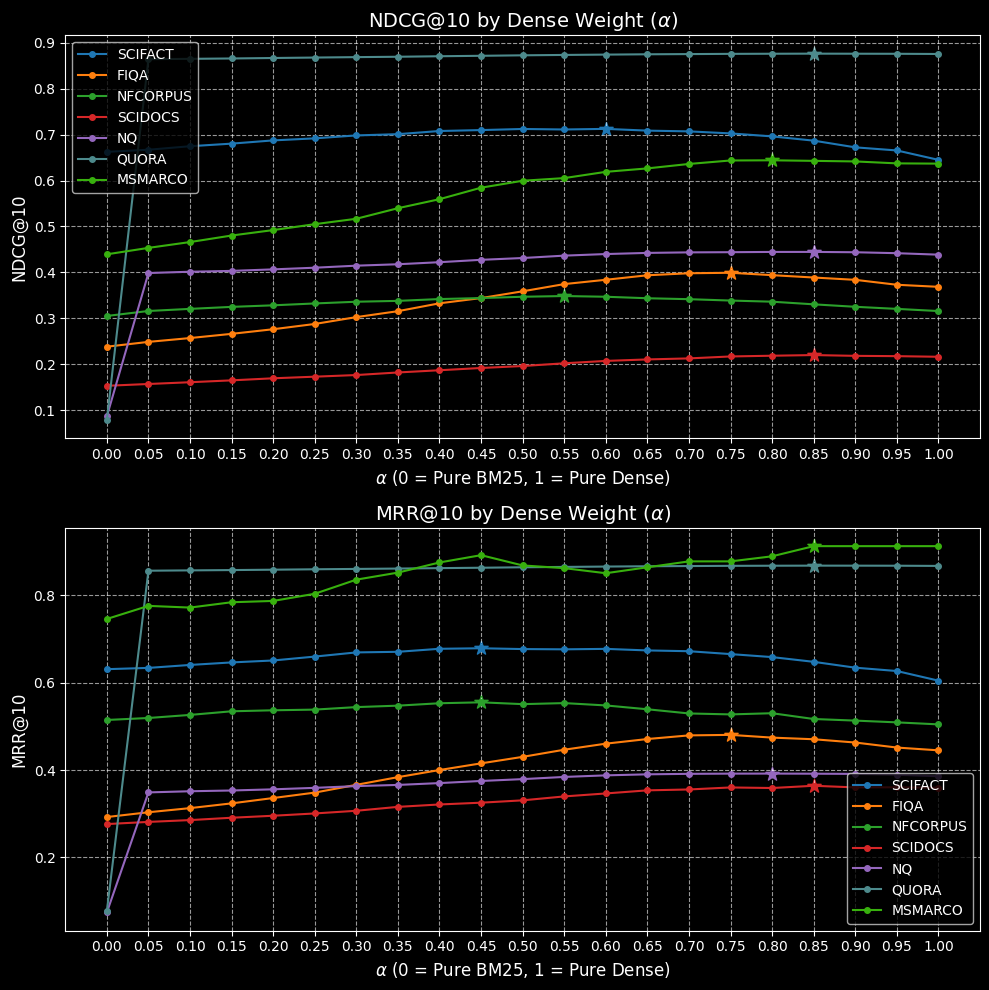

In [40]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', "#4D8A8C", "#38B00E"]

for i, ds in enumerate(datasets_list):
    ax1.plot(alphas, results_ndcg[ds], label=ds.upper(), color=colors[i], marker='o', markersize=4)
    max_idx = np.argmax(results_ndcg[ds])
    ax1.scatter(alphas[max_idx], results_ndcg[ds][max_idx], color=colors[i], s=100, marker='*')

ax1.set_title("NDCG@10 by Dense Weight ($\\alpha$)", fontsize=14)
ax1.set_xlabel("$\\alpha$ (0 = Pure BM25, 1 = Pure Dense)", fontsize=12)
ax1.set_ylabel("NDCG@10", fontsize=12)
ax1.set_xticks(alphas)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

for i, ds in enumerate(datasets_list):
    ax2.plot(alphas, results_mrr[ds], label=ds.upper(), color=colors[i], marker='o', markersize=4)
    max_idx = np.argmax(results_mrr[ds])
    ax2.scatter(alphas[max_idx], results_mrr[ds][max_idx], color=colors[i], s=100, marker='*')

ax2.set_title("MRR@10 by Dense Weight ($\\alpha$)", fontsize=14)
ax2.set_xlabel("$\\alpha$ (0 = Pure BM25, 1 = Pure Dense)", fontsize=12)
ax2.set_ylabel("MRR@10", fontsize=12)
ax2.set_xticks(alphas)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

plt.tight_layout()
# plt.savefig("hybrid_benchmark.pdf", dpi=300, format='pdf')
plt.show()

## Evaluation of dynamic router

In [42]:
def evaluate_dynamic_router(model, retrieval_data, datasets):
    model.eval()
    evaluator = EvaluateRetrieval()

    dynamic_results = {}

    device = next(model.parameters()).device

    with torch.no_grad():
        for ds in datasets:
            print(f"\n[TESTING] {ds.upper()}...")
            data = retrieval_data[ds]
            queries = data["queries"]
            qrels = data["qrels"]
            dense_norm = data["dense_norm"]
            sparse_norm = data["sparse_norm"]
            idf_dict = data["idf_dict"]
            vocab_set = data["vocab_set"]

            hybrid_results = {}
            predicted_alphas = []

            for qid, q_text in queries.items():
                if qid not in qrels:
                    continue

                x_q = CalculateFeatures.extract_features(q_text, idf_dict, vocab_set)

                x_q_tensor = torch.tensor(x_q, dtype=torch.float32).unsqueeze(0).to(device)

                alpha = model(x_q_tensor).item()
                predicted_alphas.append(alpha)

                candidate_docs = set(dense_norm.get(qid, {}).keys()) | set(sparse_norm.get(qid, {}).keys())
                hybrid_results[qid] = {}

                for did in candidate_docs:
                    s_d = dense_norm.get(qid, {}).get(did, 0.0)
                    s_s = sparse_norm.get(qid, {}).get(did, 0.0)
                    hybrid_results[qid][did] = alpha * s_d + (1.0 - alpha) * s_s

            ndcg_dict, _, _, _ = evaluator.evaluate(qrels, hybrid_results, [10])
            mrr_dict = evaluator.evaluate_custom(qrels, hybrid_results, [10], metric="mrr")
            mrr_key = list(mrr_dict.keys())[0]

            mean_alpha = np.mean(predicted_alphas)
            std_alpha = np.std(predicted_alphas)

            dynamic_results[ds] = {
                "NDCG@10": ndcg_dict["NDCG@10"],
                "MRR@10": mrr_dict[mrr_key],
                "mean_alpha": mean_alpha,
                "std_alpha": std_alpha
            }

            print(f"Dynamic NDCG@10: {ndcg_dict['NDCG@10']:.4f}")
            print(f"Dynamic MRR@10:  {mrr_dict[mrr_key]:.4f}")
            print(f"Alpha stats:     mean = {mean_alpha:.4f}, std = {std_alpha:.4f}")

    return dynamic_results

In [46]:
dynamic_results = evaluate_dynamic_router(model, rd.test_retrieval_data, datasets_list)


[TESTING] SCIFACT...
Dynamic NDCG@10: 0.7166
Dynamic MRR@10:  0.6825
Alpha stats:     mean = 0.5417, std = 0.1282

[TESTING] FIQA...
Dynamic NDCG@10: 0.3758
Dynamic MRR@10:  0.4516
Alpha stats:     mean = 0.5587, std = 0.1100

[TESTING] NFCORPUS...
Dynamic NDCG@10: 0.3316
Dynamic MRR@10:  0.5353
Alpha stats:     mean = 0.1929, std = 0.1967

[TESTING] SCIDOCS...
Dynamic NDCG@10: 0.1937
Dynamic MRR@10:  0.3263
Alpha stats:     mean = 0.4599, std = 0.1961

[TESTING] NQ...
Dynamic NDCG@10: 0.4339
Dynamic MRR@10:  0.1101
Alpha stats:     mean = 0.6310, std = 0.0864

[TESTING] QUORA...
Dynamic NDCG@10: 0.8542
Dynamic MRR@10:  0.0842
Alpha stats:     mean = 0.5806, std = 0.1163

[TESTING] MSMARCO...
Dynamic NDCG@10: 0.6419
Dynamic MRR@10:  0.8895
Alpha stats:     mean = 0.7550, std = 0.1063


## Compare with best results in static alpha

In [43]:
for i in results_ndcg.keys():
    print(f"{i} : {max(results_ndcg[i])}")

scifact : 0.71251
fiqa : 0.39928
nfcorpus : 0.34862
scidocs : 0.22012
nq : 0.44466
quora : 0.87628
msmarco : 0.64409


In [44]:
for i in results_mrr.keys():
    print(f"{i} : {max(results_mrr[i])}")

scifact : 0.6789
fiqa : 0.48054
nfcorpus : 0.55512
scidocs : 0.36396
nq : 0.39188
quora : 0.86815
msmarco : 0.91279


# SHAP

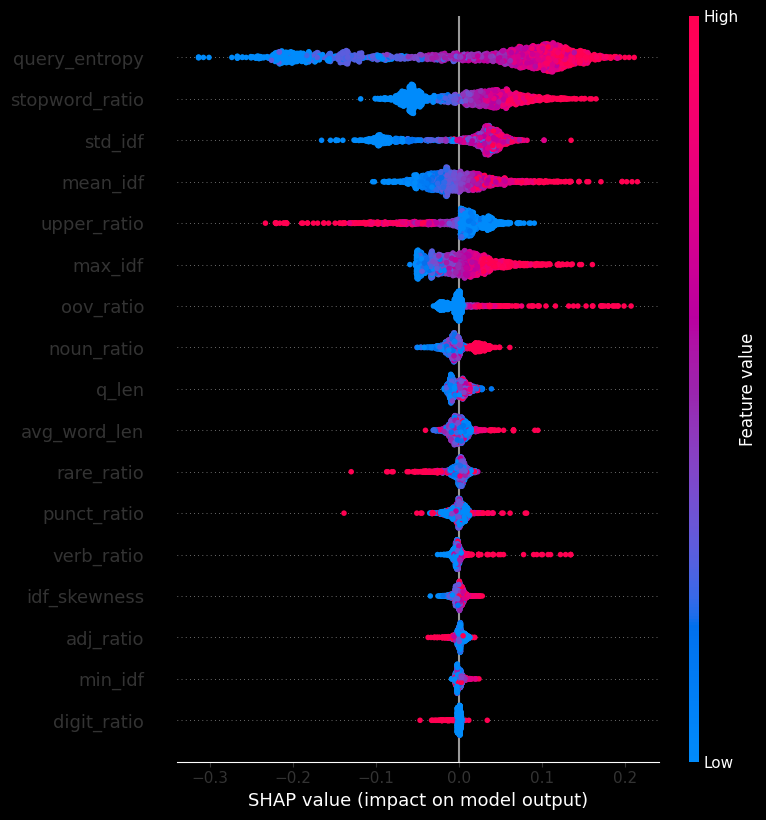

In [28]:
import shap
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

class SHAPWrapper(nn.Module):
    def __init__(self, original_model):
        super().__init__()
        self.original_model = original_model

    def forward(self, x):
        out = self.original_model(x)
        if len(out.shape) == 1:
            out = out.unsqueeze(1)
        return out

model.eval()
shap_model = SHAPWrapper(model)

sample_size = min(2000, len(global_triplets))
indices = np.random.choice(len(global_triplets), sample_size, replace=False)

X_features = [global_triplets[i]['features'] for i in indices]
X_tensor = torch.tensor(X_features, dtype=torch.float32)

background = X_tensor[:100]
explainer = shap.DeepExplainer(shap_model, background)

test_samples = X_tensor[100:]
shap_values = explainer.shap_values(test_samples)


feature_names = [
    "q_len", "mean_idf", "max_idf", "min_idf", "std_idf",
    "rare_ratio", "oov_ratio", "idf_skewness", "query_entropy", "digit_ratio", "upper_ratio",
    "punct_ratio", "stopword_ratio", "noun_ratio",
    "verb_ratio", "adj_ratio", "avg_word_len"
]

plt.figure(figsize=(12, 8))
if isinstance(shap_values, list):
    shap_values = shap_values[0]

shap_vals_2d = np.array(shap_values).reshape(-1, 17)
test_samples_2d = test_samples.numpy().reshape(-1, 17)

shap.summary_plot(shap_vals_2d, test_samples_2d, feature_names=feature_names)